# Petrol Price Forecasting

#### Life Cycle of Machine Learning Project

* Understanding the Problem Statement
* Data Collection
* Data check to perform
* Exploratory Data Analysis
* Data Pre-Processing
* Model Training
* Choose best model

### 1) Problem Statement

* The ONGCF is a organization dedicated to the exploration and production of oil and natural gas.Price information is supplied on a weekly basis. It seeks to forecast crude oil prices for the following 16 months, from January 1, 2019 to April 1, 2020.Forecast the prices based upon the best model as per your choice. Check for outliers and missing values.


### 2) Data Collection

* Dataset Source - 
* The data consists of 2 column and 813 rows. 

### 2.1 Import Data and Required Packages

#### Importing Pandas, Numpy, Matplotlib, Plotly.express and Warning Library.

In [1]:

import numpy as np
import pandas as pd


#### Import the CSV Data as Pandas DataFrame

In [2]:
dataset=pd.read_csv("train_data.csv")

#### Show Top 5 Records

In [3]:
dataset.head(5)

,Date,Petrol (USD)
0,6/9/2003,74.59
1,6/16/2003,74.47
2,6/23/2003,74.42
3,6/30/2003,74.35
4,7/7/2003,74.28


#### Shape of Dataset

In [4]:
dataset.shape

(813, 2)

### 2.2 Dataset information

* Date : Given the date when petrol price is decreased or increased
* Price : This is the Dependent variable

### 3) Data Checks to Perform

* Check Missing values
* Check Duplicates
* Check data type
* Check statistic of data set

### 3.1 Check Missing values

In [5]:
dataset.isnull().sum()

Date            0
Petrol (USD)    2
dtype: int64

###### There are two missing values in the data set

### 3.2 Check Duplicates

In [6]:
dataset.duplicated().sum()

0

###### There are no duplicates values in the data set

### 3.3 Check data types

In [7]:
dataset.dtypes

Date             object
Petrol (USD)    float64
dtype: object

### 3.5 Check statistics of data set

In [8]:
dataset.describe()

,Petrol (USD)
count,811.000000
mean,110.330481
std,19.241182
min,74.210000
25%,94.525000
50%,112.420000
75%,128.560000
max,189.510000


### 3.6 Filling the Missing value

In [9]:
dataset.fillna(method = 'bfill', inplace=True)

## 4. Exploring Data (Visualization)

* Bar Plot
* Box plot

### Bar Plot

In [10]:
import plotly.express as px
import pandas as pd

fig = px.bar(dataset, x='Date', y='Petrol (USD)')
fig.show()

### Box Plot

In [11]:
fig3 = px.box(dataset, y= 'Petrol (USD)')
fig3.show()

### For removing Outliers

In [12]:
import numpy as np
print(np.where(dataset['Petrol (USD)']>180))

(array([ 79, 142], dtype=int32),)


In [13]:
Q1 = np.percentile(dataset['Petrol (USD)'], 25,
                   interpolation = 'midpoint')
 
Q3 = np.percentile(dataset['Petrol (USD)'], 75,
                   interpolation = 'midpoint')
IQR = Q3 - Q1
print("IQR",IQR)
print("Old Shape: ", dataset.shape)
 
# Upper bound
upper = np.where(dataset['Petrol (USD)'] >= (Q3+1.5*IQR))
print('upper',upper)
# Lower bound
lower = np.where(dataset['Petrol (USD)'] <= (Q1-1.5*IQR))
print('lower',lower)

''' Removing the Outliers '''
dataset.drop(upper[0], inplace = True)
dataset.drop(lower[0], inplace = True)
 
print("New Shape: ", dataset.shape)

IQR 34.140000000000015
Old Shape:  (813, 2)
upper (array([ 79, 142], dtype=int32),)
lower (array([], dtype=int32),)
New Shape:  (811, 2)


In [14]:
fig3 = px.box(dataset, y= 'Petrol (USD)')
fig3.show()

### Converting Float data type into Numeric data type

In [15]:
import numpy as geek
from datetime import datetime, timedelta

Day  = geek.arange(811)
Month =geek.arange(811)
Year = geek.arange(811)
Date_sum = geek.arange(811)

for i in range(0,811):
   
    date = dataset.iloc[i,0]
    split_date = date.split('/')
    new_date = [eval(i) for i in split_date]
    month= new_date[0]
    day= new_date[1]
    year= new_date[2]
    Day[i] = day
    Month[i] = month
    Year[i] = year
    date_str = datetime(year=year, month=month, day=day)
    Date_sum[i] = (date_str.year*10000 +date_str.month * 100 +date_str.day * 1)

In [16]:
dataset['Day'] = Day
dataset['Month'] = Month
dataset['Year'] = Year
dataset['Date_sum'] = Date_sum

In [17]:
dataset.head()

,Date,Petrol (USD),Day,Month,Year,Date_sum
0,6/9/2003,74.59,9,6,2003,20030609
1,6/16/2003,74.47,16,6,2003,20030616
2,6/23/2003,74.42,23,6,2003,20030623
3,6/30/2003,74.35,30,6,2003,20030630
4,7/7/2003,74.28,7,7,2003,20030707


In [18]:
dataset.dtypes

Date             object
Petrol (USD)    float64
Day               int32
Month             int32
Year              int32
Date_sum          int32
dtype: object

In [19]:
dataset.isnull().sum()

Date            0
Petrol (USD)    0
Day             0
Month           0
Year            0
Date_sum        0
dtype: int64

### Preparing X and Y variables

In [20]:
x = dataset.drop(columns = ['Date','Petrol (USD)'])
y = dataset['Petrol (USD)']
x.head()

,Day,Month,Year,Date_sum
0,9,6,2003,20030609
1,16,6,2003,20030616
2,23,6,2003,20030623
3,30,6,2003,20030630
4,7,7,2003,20030707


In [21]:
dataset.corr()

,Petrol (USD),Day,Month,Year,Date_sum
Petrol (USD),1.000000,0.005059,0.017800,0.723440,0.723806
Day,0.005059,1.000000,0.007869,-0.003968,-0.003714
Month,0.017800,0.007869,1.000000,-0.045047,-0.037414
Year,0.723440,-0.003968,-0.045047,1.000000,0.999971
Date_sum,0.723806,-0.003714,-0.037414,0.999971,1.000000


In [22]:
dataset.describe()

,Petrol (USD),Day,Month,Year,Date_sum
count,811.000000,811.000000,811.000000,811.000000,8.110000e+02
mean,110.090900,15.765721,6.611591,2010.723798,2.010791e+07
std,18.897387,8.811152,3.440257,4.501047,4.499625e+04
min,74.210000,1.000000,1.000000,2003.000000,2.003061e+07
25%,94.405000,8.000000,4.000000,2007.000000,2.007051e+07
50%,112.350000,16.000000,7.000000,2011.000000,2.011033e+07
75%,128.430000,23.000000,10.000000,2015.000000,2.015021e+07
max,142.170000,31.000000,12.000000,2018.000000,2.018123e+07


In [23]:
test = x[:1]
print(test)
y[:1]

   Day  Month  Year  Date_sum
0    9      6  2003  20030609


0    74.59
Name: Petrol (USD), dtype: float64

In [24]:
y=pd.DataFrame(y)

###  Separate dataset into Train and Test 

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30,random_state = 45)

In [26]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((567, 4), (567, 1), (244, 4), (244, 1))

### Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [28]:
model.score(x_test,y_test)

0.5095336372587281

In [29]:
y_pred = model.predict(x_test)
print(y_pred.shape)

(244, 1)


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [31]:
a= mean_squared_error(y_test,y_pred)
a

170.5903996098521

In [32]:
import math
RMSE = math.sqrt(a)
RMSE

13.06102597845407

In [33]:
mean_absolute_error(y_test,y_pred)

11.17636993959649

In [34]:
r2_score(y_test,y_pred)

0.5095336372587281

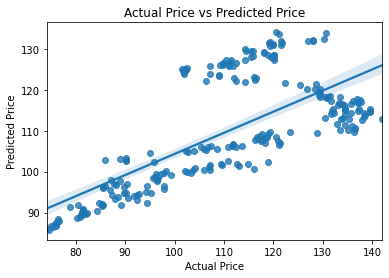

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.regplot(x = y_test,y = y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

### Random Forest

In [36]:
n_estimators = [5,20,50,100,200,400,500,600,1000]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 120, num = 12)]
min_samples_split = [2, 6, 10,121,4,15,23,25]
min_samples_leaf = [1, 3, 4,5,6,7,9,13]
bootstrap = [True, False]

random_grid = {'n_estimators': n_estimators,

'max_features': max_features,

'max_depth': max_depth,

'min_samples_split': min_samples_split,

'min_samples_leaf': min_samples_leaf,

'bootstrap': bootstrap}

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
model = RandomForestRegressor(n_estimators= 20, min_samples_split= 6, min_samples_leaf= 3, max_features= 'sqrt', max_depth= 90, bootstrap= True)

In [39]:
model.fit(x_train,y_train)

<ipython-input-39-4719cf73997a>:1: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestRegressor(max_depth=90, max_features='sqrt', min_samples_leaf=3,
                      min_samples_split=6, n_estimators=20)

In [40]:
y_pred = model.predict(x_test)

In [41]:
print(y_pred)

[138.44171429 104.45878902 116.04261523 102.58258445  81.35679643
 117.54250952  93.29034742  90.9346447  133.0896123  136.4595
 133.730775   120.86947165 108.11983187  84.51371567 120.69199149
 116.17403631  89.45428994 109.95521825  96.09969502 102.75841799
 104.23094016  81.65870952 111.20842619 127.32662063 117.98057222
  76.93411667 117.63948745 134.74999737 129.68825467 136.11077549
 108.68023685 103.89507009 131.64983864 134.96264751 119.01160119
 134.62449563 133.59994848  93.85249206  80.72298313 117.33634345
  77.45086071 112.02001329 116.75202778 135.29529841  76.77347341
  88.74300238 104.33808315  87.85505774 135.54395038  93.76620218
 114.90141071 119.38023373  95.71158512  82.03154762 128.95286012
 134.3899587  116.7314756  117.98979464  95.57565456  88.4719131
 115.77062024  93.92386461 117.72609698 119.47866151 112.75488988
 112.4262131  104.76173846  84.6075871  128.81873983 108.47556827
  93.33891223 129.26897143  89.85053231 106.13223703 120.59207522
  82.7841994   

In [42]:
import pickle

In [43]:
pickle.dump(y_pred,open('model.pkl','wb'))
model=pickle.load(open('model.pkl','rb'))

In [44]:
a=y_pred.sum()
a

26868.36983099262

In [45]:
b=y_test.sum()

In [47]:
errors = abs(a-b)
# Print out the mean absolute error (mae)
print('Mean Absolute Error:', round(np.mean(errors), 2), 'degrees.')

# Calculate mean absolute percentage error (MAPE)
mape = 100 * (errors / b)
# Calculate and display accuracy
accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 2), '%.')

Mean Absolute Error: 1.76 degrees.
Accuracy: 99.99 %.


### ARIMA

c:\Users\DEll\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\DEll\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\DEll\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\DEll\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

c:\Users\DEll\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:376: ValueWarning:

No supported index is available

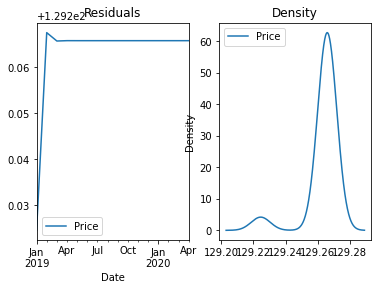

RMSE: 4.5160660704279065
Future predictions:                  Price
Date                  
2019-01-01  129.224561
2019-02-01  129.267564
2019-03-01  129.265742
2019-04-01  129.265820
2019-05-01  129.265816
2019-06-01  129.265816
2019-07-01  129.265816
2019-08-01  129.265816
2019-09-01  129.265816
2019-10-01  129.265816
2019-11-01  129.265816
2019-12-01  129.265816
2020-01-01  129.265816
2020-02-01  129.265816
2020-03-01  129.265816
2020-04-01  129.265816


In [48]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('train_data.csv')

# Preprocess data
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Split data into training and testing sets
train_data = data.iloc[:-16] 
test_data = data.iloc[-16:]  

# Select ARIMA parameters
p = 1  
d = 1  
q = 1 

# Train the model
model = ARIMA(train_data, order=(p, d, q))
model_fit = model.fit()

# Test the model
test_predictions = model_fit.forecast(steps=16)
mse = mean_squared_error(test_data, test_predictions)
rmse = sqrt(mse)

# Make predictions
future_data = pd.date_range(start='2019-01-01', end='2020-04-01', freq='MS')
future_predictions = model_fit.forecast(steps=16)
future_df = pd.DataFrame({'Date': future_data, 'Price': future_predictions})
future_df.set_index('Date', inplace=True)

fig,ax = plt.subplots(1,2)
future_df.plot(title = 'Residuals', ax = ax[0])
future_df.plot(kind = 'kde', title = 'Density', ax= ax[1])
plt.show()

print('RMSE:', rmse)
print('Future predictions:', future_df)